Test R^2: 0.667 | RMSE: 4.945 | MAE: 3.211
5-Fold R^2: mean=0.715, std=0.038
        y_pred  y_true
173  28.985567    23.6
274  36.007252    32.4
491  14.843877    13.6
72   25.020672    22.8
452  18.773787    16.1
76   23.261914    20.0
316  17.669567    17.8
140  14.350790    14.0
471  23.020689    19.6
500  20.625099    16.8


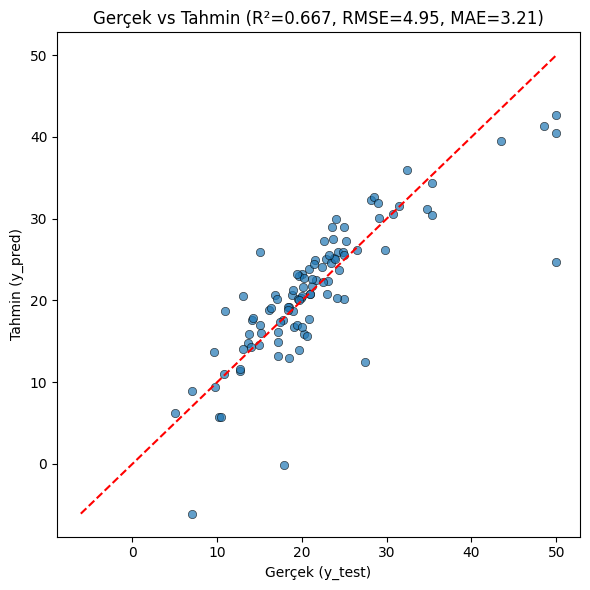

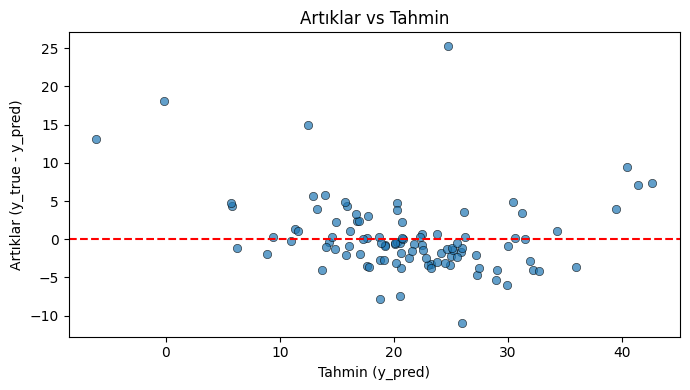

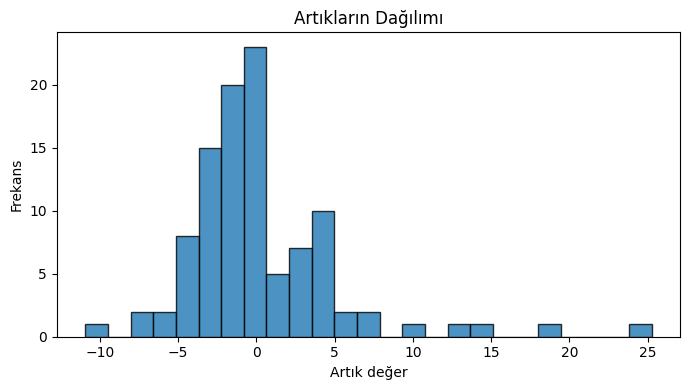

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split,learning_curve, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# 1) Veri
df = pd.read_csv("BostonHousing.csv")

# Hedef değişkeni ismi genelde MEDV olur; emin olmak için:
target_col = "MEDV" if "MEDV" in df.columns else df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col]

# 2) Train/Test split (önce ayır, sonra preprocessing'i sadece train'e fit et)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3) Pipeline: sadece sayısal sütunlara median impute (mean de olur)
pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

# 4) Eğitim
pipe.fit(X_train, y_train)

# 5) Tahmin ve metrikler
y_pred = pipe.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"Test R^2: {r2:.3f} | RMSE: {rmse:.3f} | MAE: {mae:.3f}")

# Artıklar
residuals = y_test - y_pred



# (İsteğe bağlı) K-Fold CV ile genel performans
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(pipe, X, y, cv=cv, scoring="r2")
print(f"5-Fold R^2: mean={cv_r2.mean():.3f}, std={cv_r2.std():.3f}")

# (İsteğe bağlı) Tahmin/gerçek karşılaştırması
compare = pd.DataFrame({"y_pred": y_pred, "y_true": y_test})
print(compare.head(10))

# ===============================
# 4) Grafikler
# ===============================

# 4.1 Gerçek vs Tahmin (parity plot)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7, edgecolor="k", linewidth=0.5)
lims = [
    np.min([y_test.min(), y_pred.min()]),
    np.max([y_test.max(), y_pred.max()])
]
plt.plot(lims, lims, "r--", linewidth=1.5)  # y = x hattı
plt.xlabel("Gerçek (y_test)")
plt.ylabel("Tahmin (y_pred)")
plt.title(f"Gerçek vs Tahmin (R²={r2:.3f}, RMSE={rmse:.2f}, MAE={mae:.2f})")
plt.tight_layout()
plt.show()

# 4.2 Artıklar vs Tahmin
plt.figure(figsize=(7, 4))
plt.scatter(y_pred, residuals, alpha=0.7, edgecolor="k", linewidth=0.5)
plt.axhline(0, color="r", linestyle="--", linewidth=1.5)
plt.xlabel("Tahmin (y_pred)")
plt.ylabel("Artıklar (y_true - y_pred)")
plt.title("Artıklar vs Tahmin")
plt.tight_layout()
plt.show()

# 4.3 Artık histogramı
plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=25, alpha=0.8, edgecolor="k")
plt.xlabel("Artık değer")
plt.ylabel("Frekans")
plt.title("Artıkların Dağılımı")
plt.tight_layout()
plt.show()

# 4.4 Öğrenme eğrisi (R^2 ve/veya RMSE)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
train_sizes, train_scores, valid_scores = learning_curve(
    pipe, X, y, cv=cv, scoring="r2", train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
)
train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)

plt.figure(figsize=(7, 4))
plt.plot(train_sizes, train_mean, marker="o", label="Train R²")
plt.plot(train_sizes, valid_mean, marker="s", label="CV R²")
plt.xlabel("Eğitim seti boyutu")
plt.ylabel("R²")
plt.title("Öğrenme Eğrisi (R²)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4.5 Katsayı grafiği (|coef| büyükten küçüğe)
# Not: Katsayılar standartlaştırılmış özellikler üzerinedir.
lin_model = pipe.named_steps["model"]
coefs = lin_model.coef_
feat_names = X.columns

coef_df = pd.DataFrame({"feature": feat_names, "coef": coefs})
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

plt.figure(figsize=(8, max(4, 0.35 * len(coef_df))))
plt.barh(coef_df["feature"], coef_df["coef"])
plt.gca().invert_yaxis()
plt.xlabel("Katsayı (standartlaştırılmış ölçekte)")
plt.title("Lineer Regresyon Katsayıları (|coef| sıralı)")
plt.tight_layout()
plt.show()


## Metrikler ne anlatır?

* **R² (r2\_score)**
  Açıklanan varyans oranı. **1.0** → kusursuz; **0.0** → “hep ortalama tahmin etmekle aynı”; **negatif** → ortalama tahminden **daha kötü**.

  > Yüksek daha iyidir. 0.7 ≈ verideki oynaklığın %70’ini açıklıyorsun gibi yorumlanır.

* **MSE / RMSE**
  Hata karelerinin ortalaması (MSE) ve karekökü (RMSE). **Ölçü birimi hedef değişkenle aynıdır.**

  > Düşük daha iyidir. RMSE büyük hataları daha çok cezalandırır.

* **MAE**
  Mutlak hataların ortalaması. Aykırı değerlere RMSE kadar duyarlı değildir.

  > Düşük daha iyidir. “Ortalama kaç birim sapıyorum?” sorusunun yalın cevabı.

* **5-Fold R²: mean ± std**
  Ortalama daha yüksekse **genel başarı**, std küçükse **istikrar** iyidir. Std büyükse model veri bölünmesine hassastır.

---
